In [ ]:
import os
import pandas as pd
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

# 1. Trỏ đường dẫn tới thư mục artifacts chứa dữ liệu đã xử lý
# Dùng '..' để lùi từ thư mục 'notebooks' ra thư mục gốc
ARTIFACTS_DIR = os.path.join('..', 'artifacts')

print(f"📂 Đang nạp dữ liệu từ: {ARTIFACTS_DIR}")

# 2. Đọc dữ liệu Train/Test đã được xử lý hoàn chỉnh từ file .py
X_train = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'X_train.csv'))
X_test = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'X_test.csv'))

# y_train và y_test đọc vào dưới dạng Pandas Series (lấy cột Churn)
y_train = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'y_train.csv'))['Churn']
y_test = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'y_test.csv'))['Churn']

print(f"✅ Đã nạp thành công! Kích thước X_train: {X_train.shape}")
# Hiển thị thử 3 dòng đầu để kiểm tra tên cột
X_train.head(3)

📂 Đang nạp dữ liệu từ: ..\artifacts
✅ Đã nạp thành công! Kích thước X_train: (5634, 25)


,encoder__Dependents_Yes,encoder__PaymentMethod_Credit card (automatic),encoder__PaymentMethod_Electronic check,encoder__PaymentMethod_Mailed check,encoder__InternetService_Fiber optic,encoder__InternetService_No,encoder__tenure_group_13-24 months,encoder__tenure_group_25-36 months,encoder__tenure_group_37-48 months,encoder__tenure_group_49-60 months,...,remainder__PaperlessBilling,remainder__MonthlyCharges,remainder__TotalCharges,remainder__OnlineSecurity,remainder__OnlineBackup,remainder__DeviceProtection,remainder__TechSupport,remainder__service_diversity,remainder__monthly_charges_ratio,remainder__is_paperless_electronic
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1,94.10,5475.9,1,1,0,0,2,1.453019,1
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0,19.35,212.3,0,0,0,0,0,0.298788,0
2,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1,80.45,137.1,1,0,1,0,2,1.242247,0


C:\Users\Muich\AppData\Local\Temp\ipykernel_536\3274371986.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Clean_Feature', data=coef_df, palette=colors)


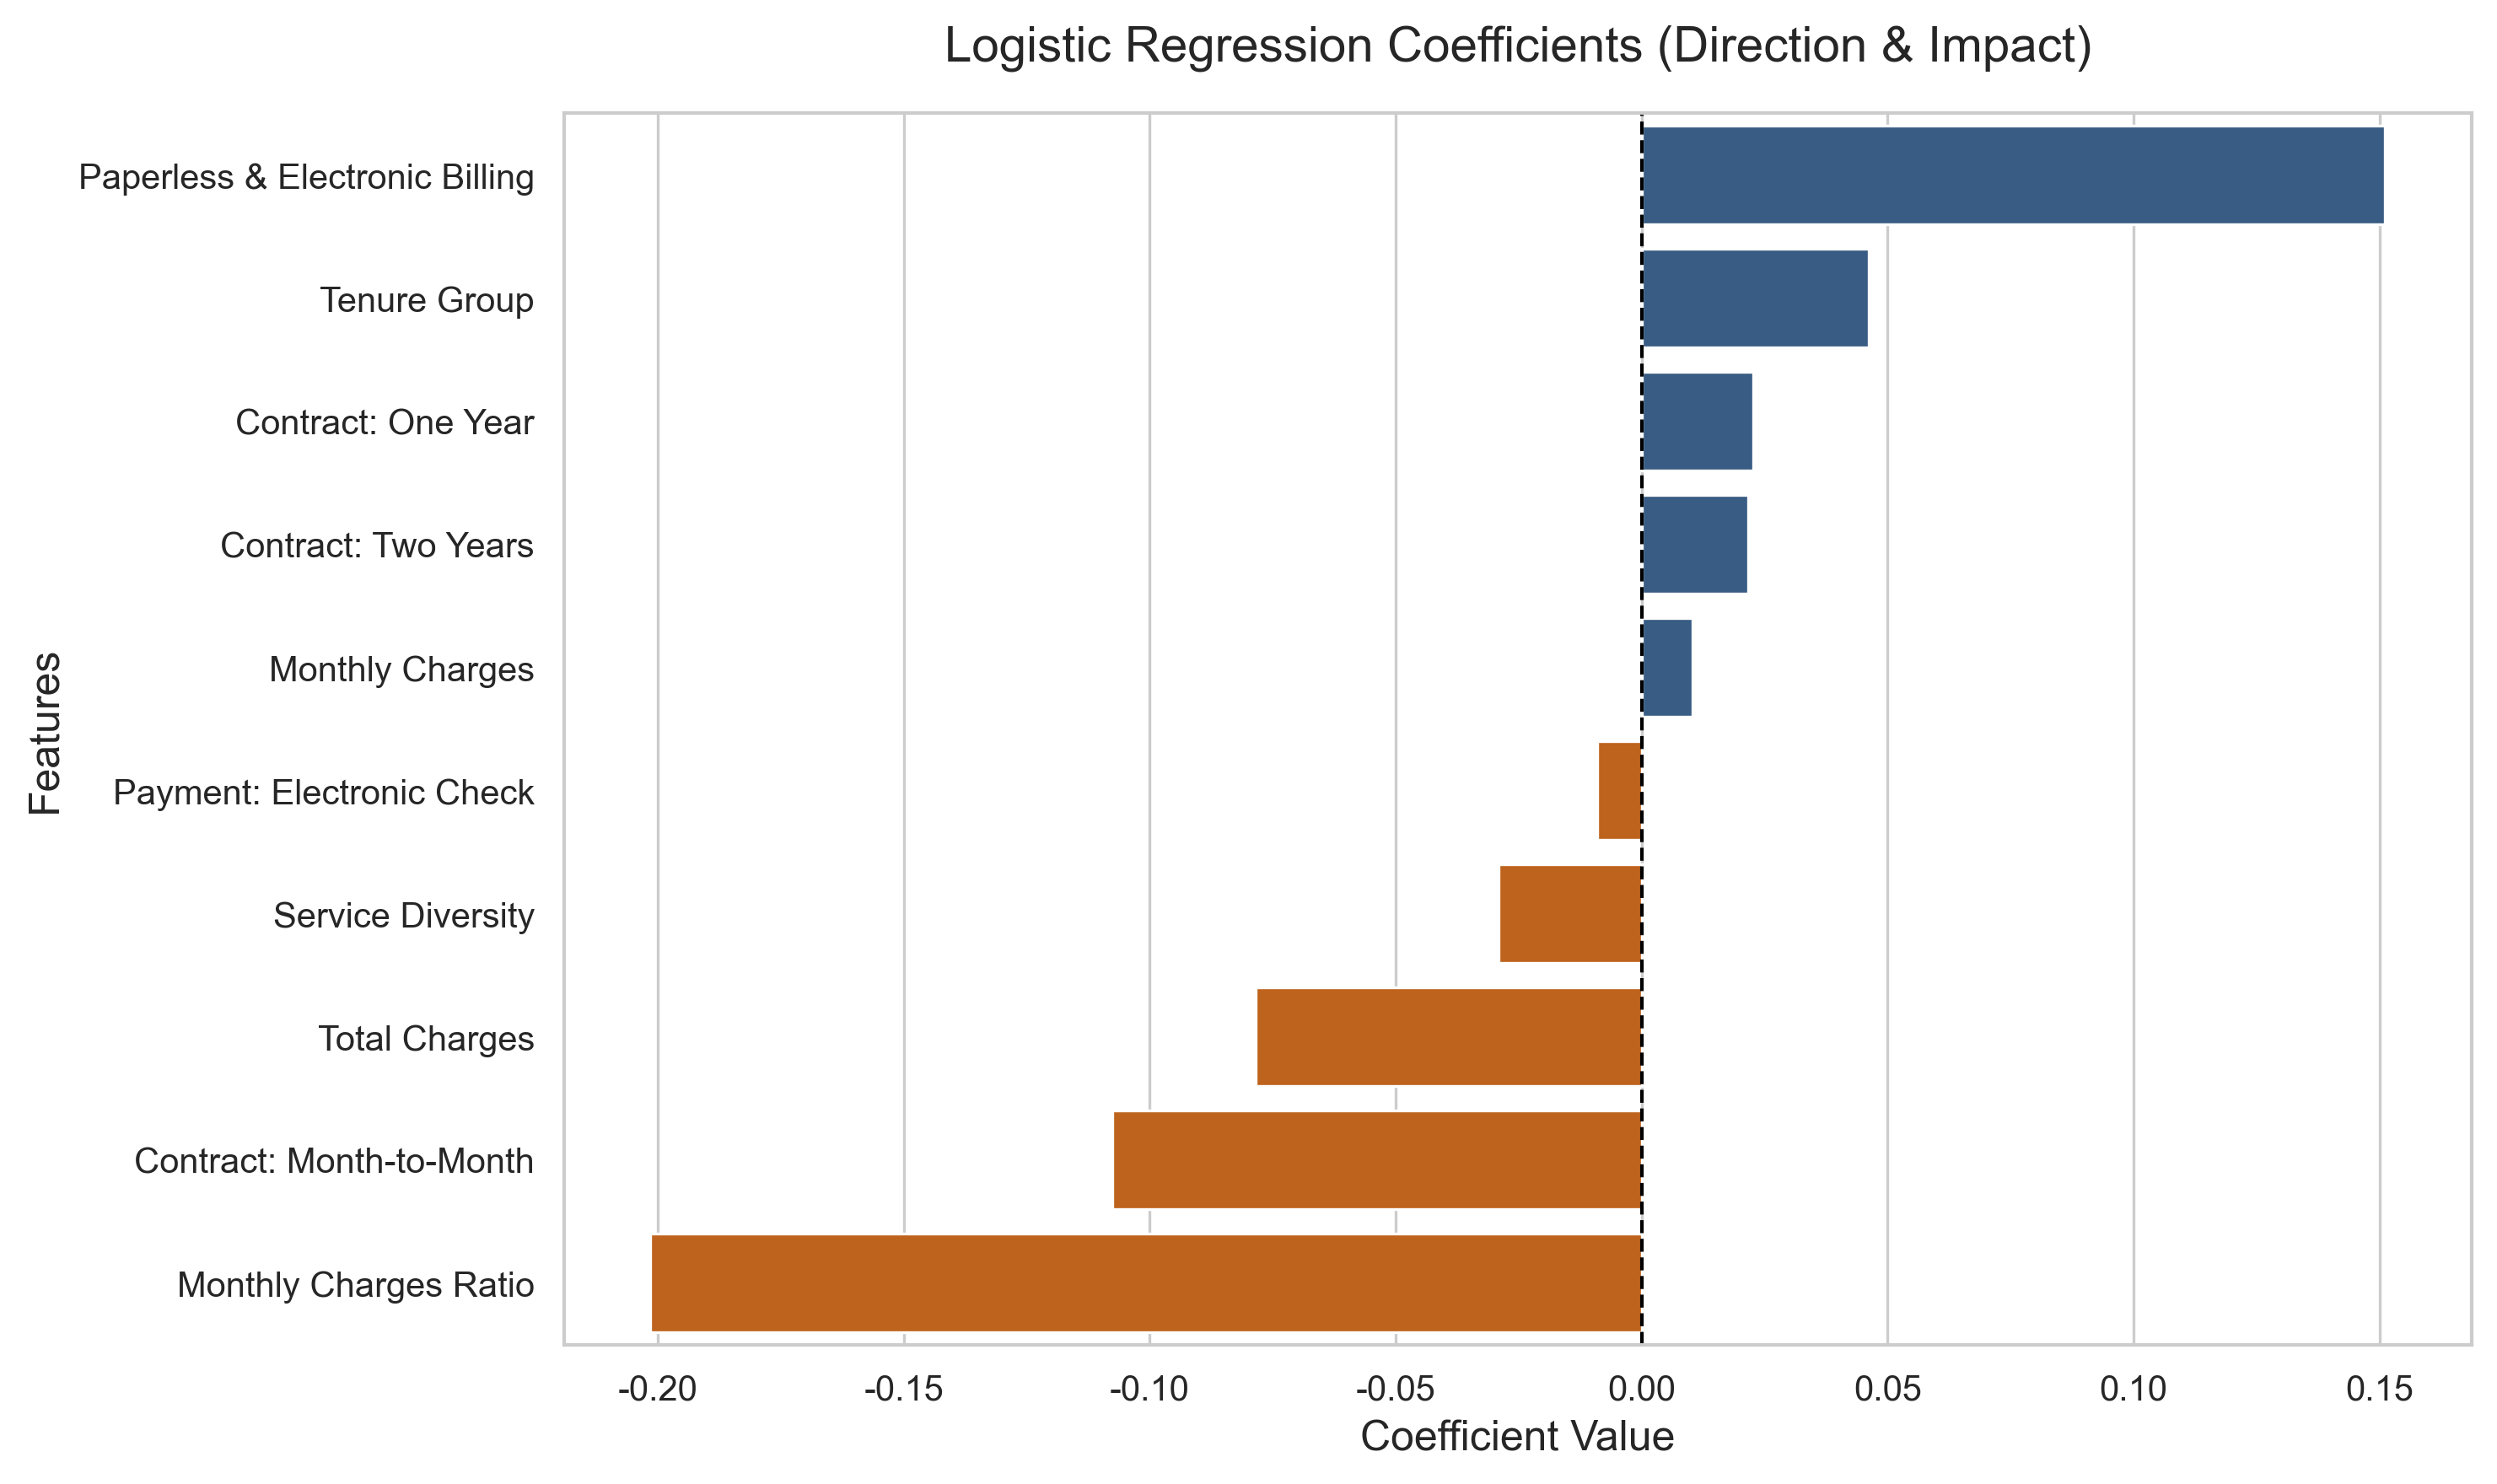

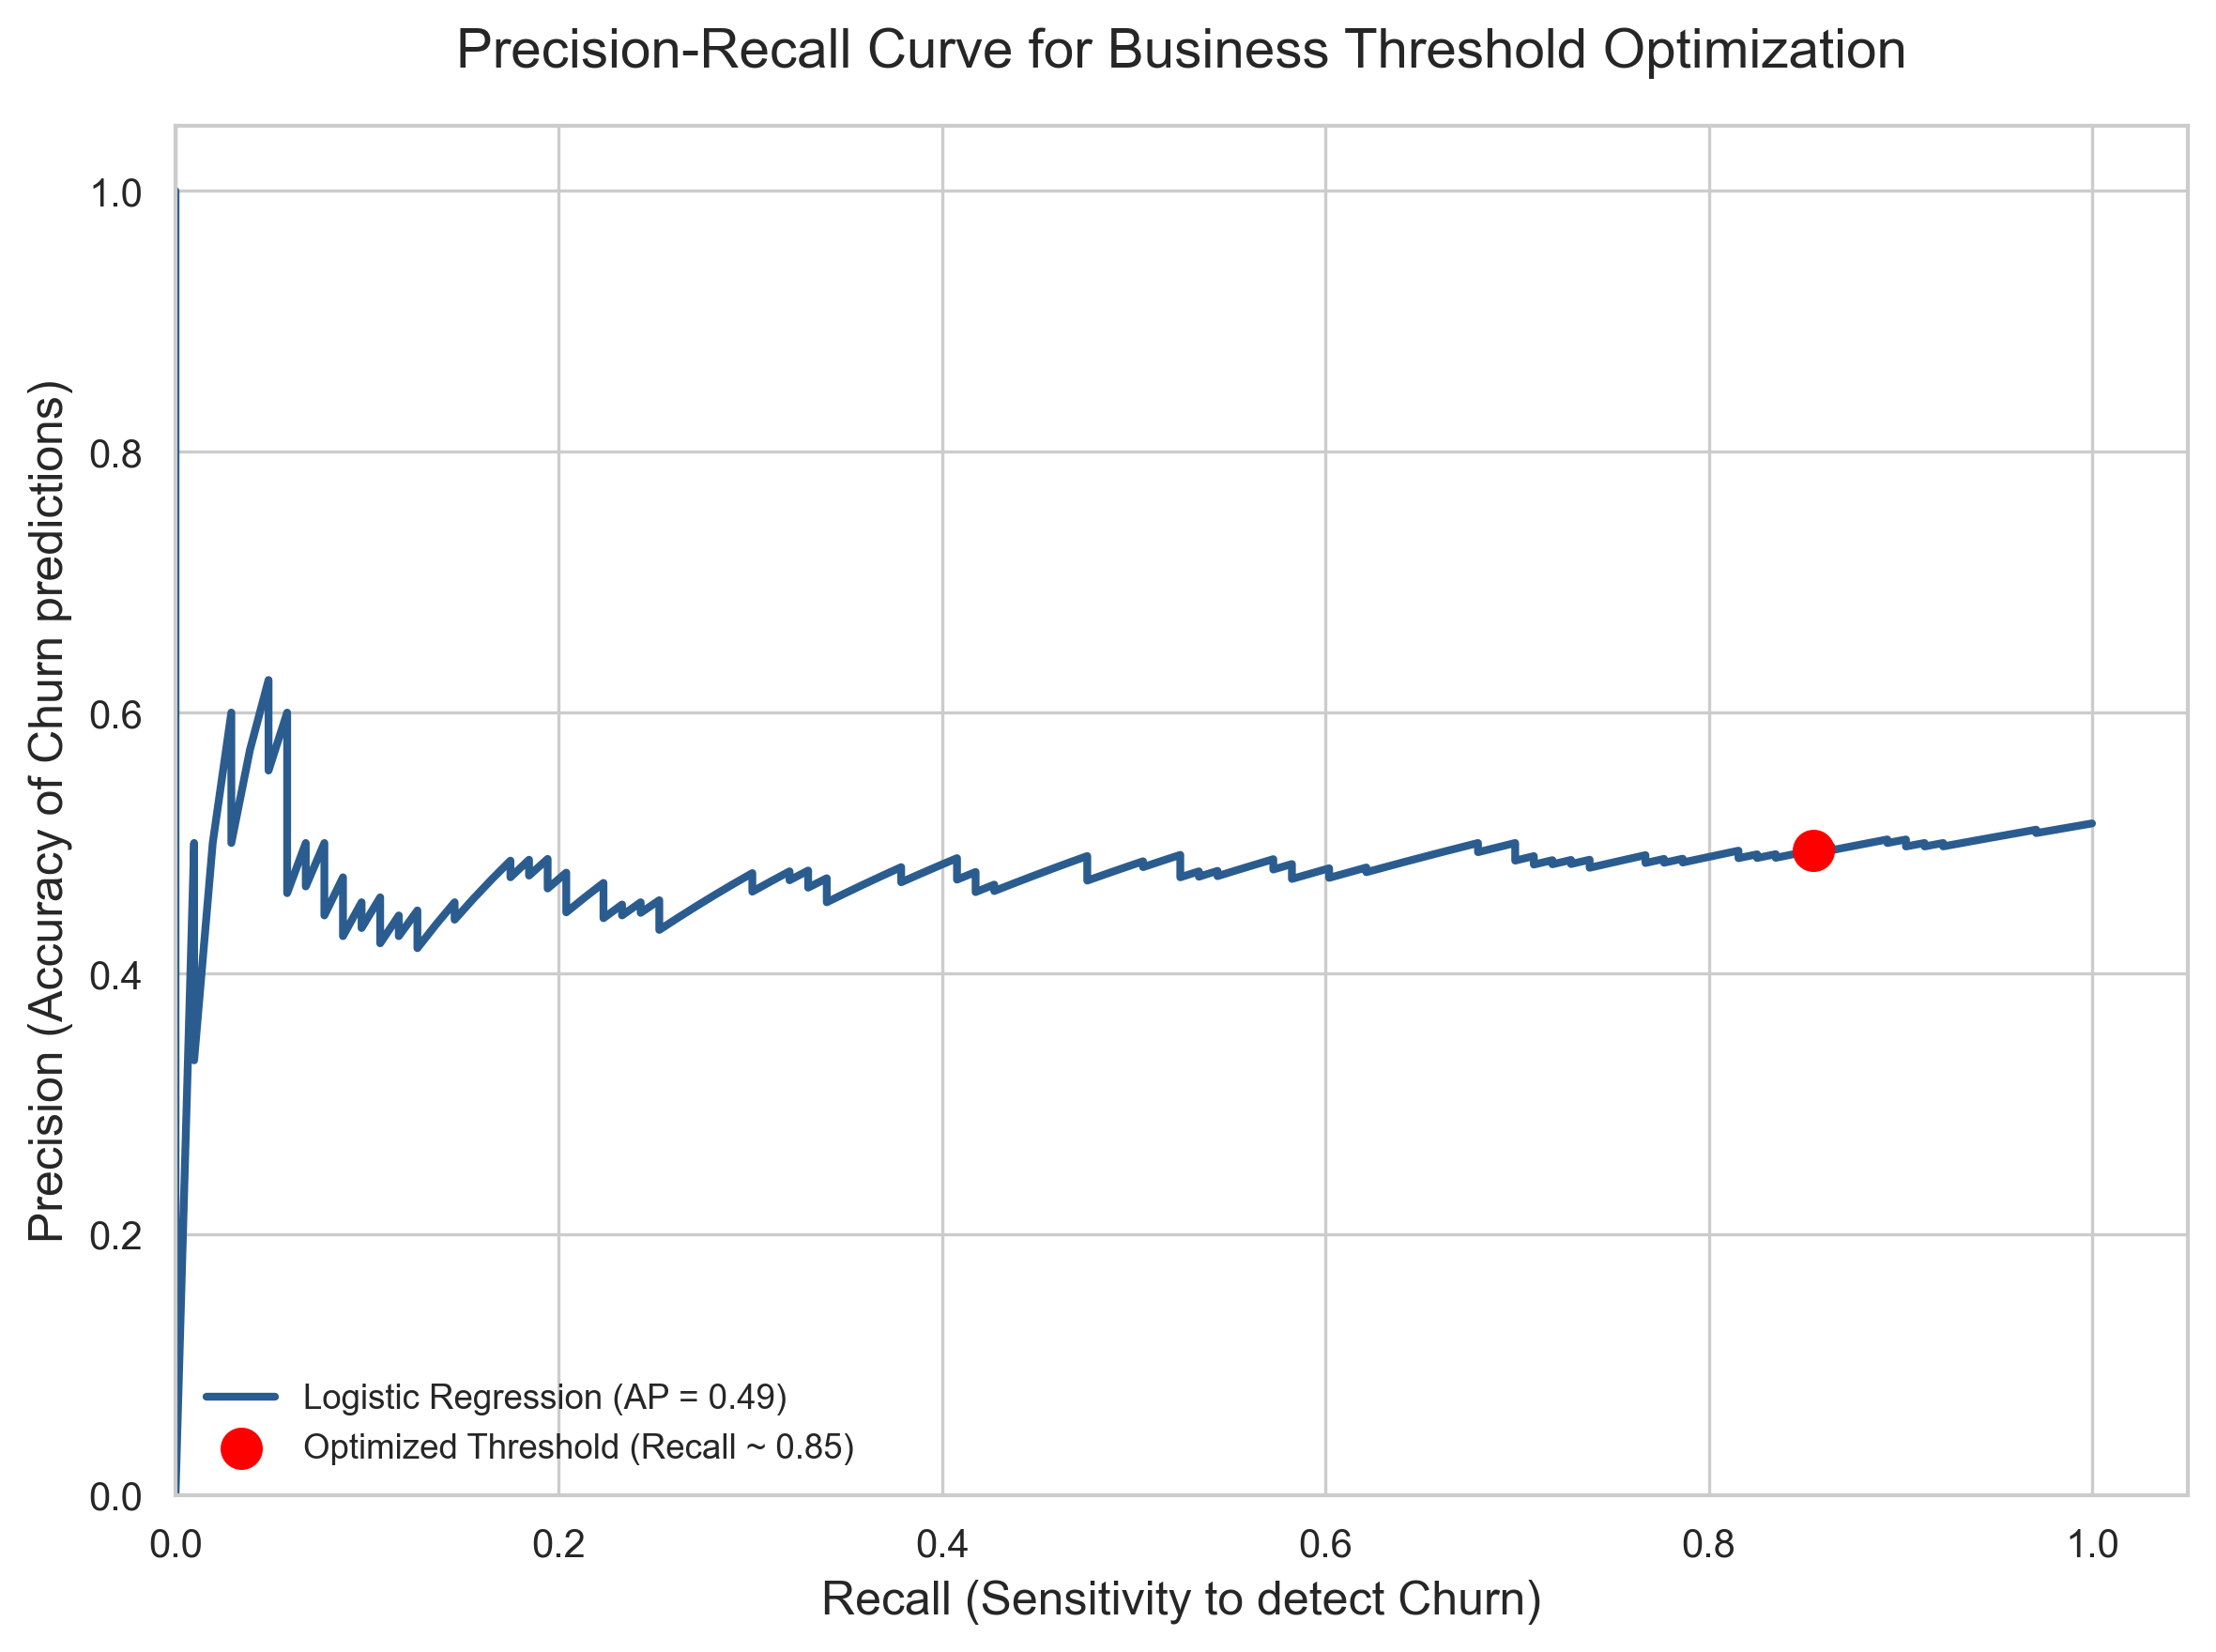

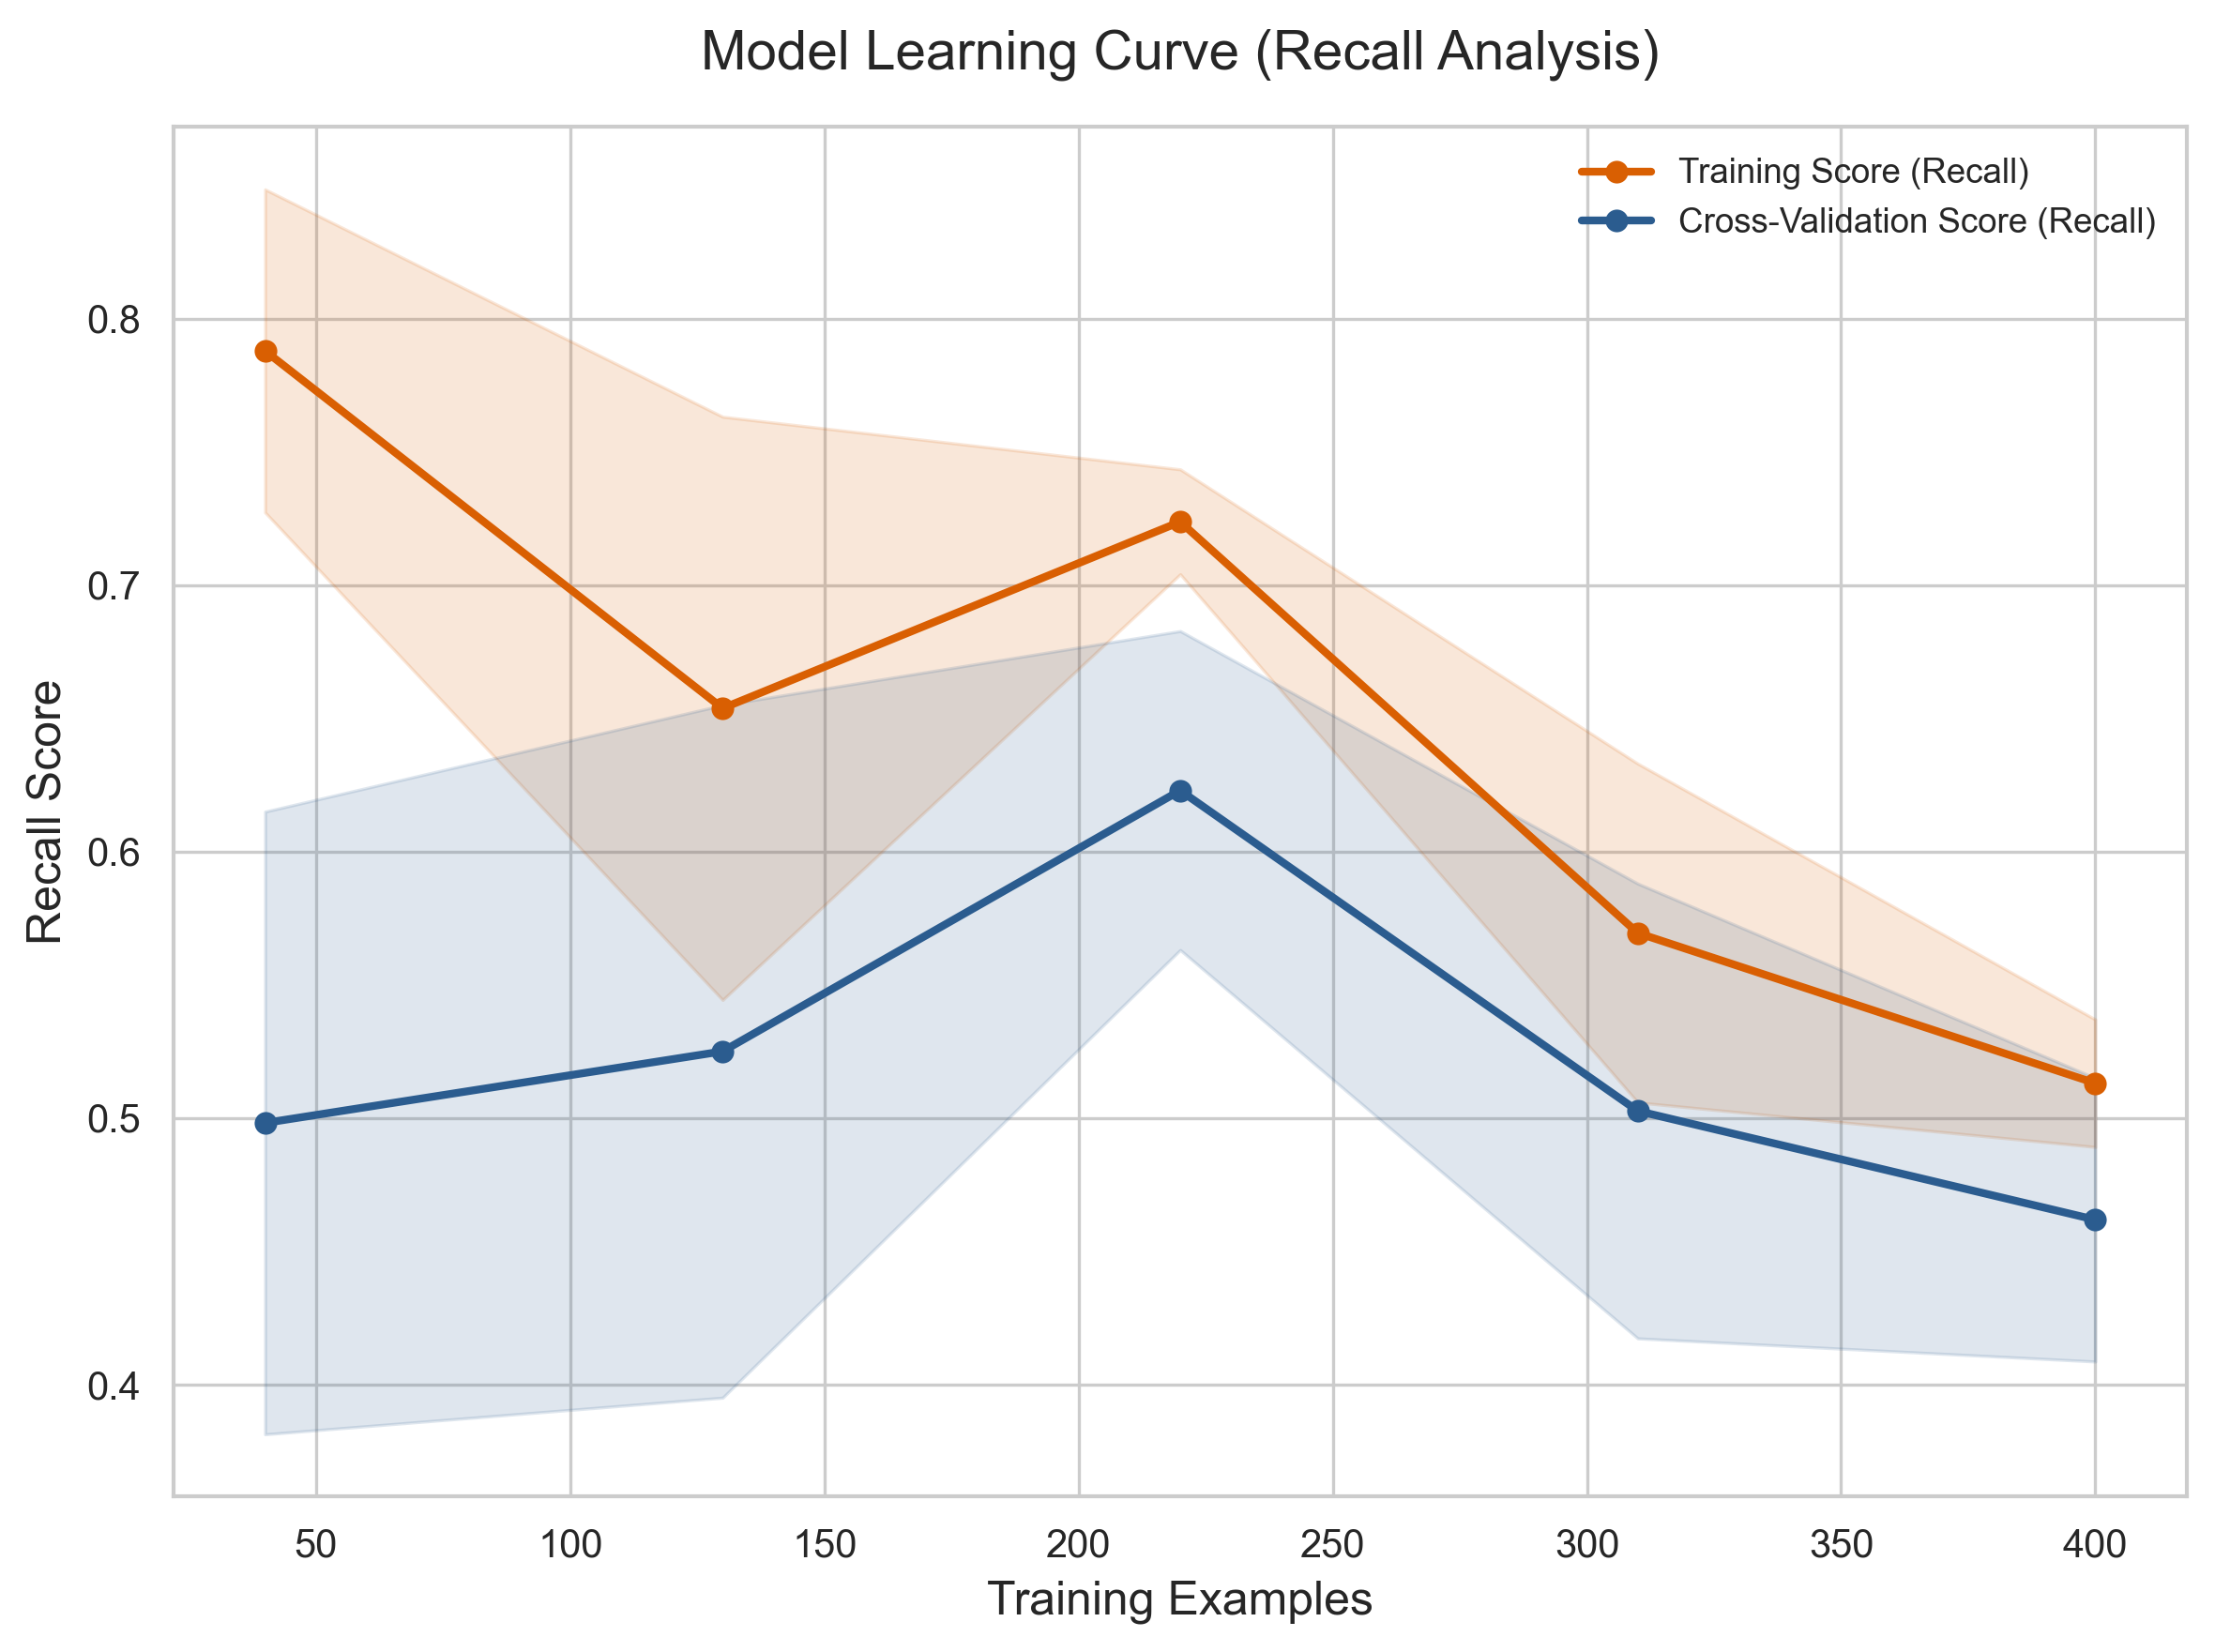

Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.
C:\Users\Muich\AppData\Local\Temp\ipykernel_536\3274371986.py:151: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_clean, show=False)


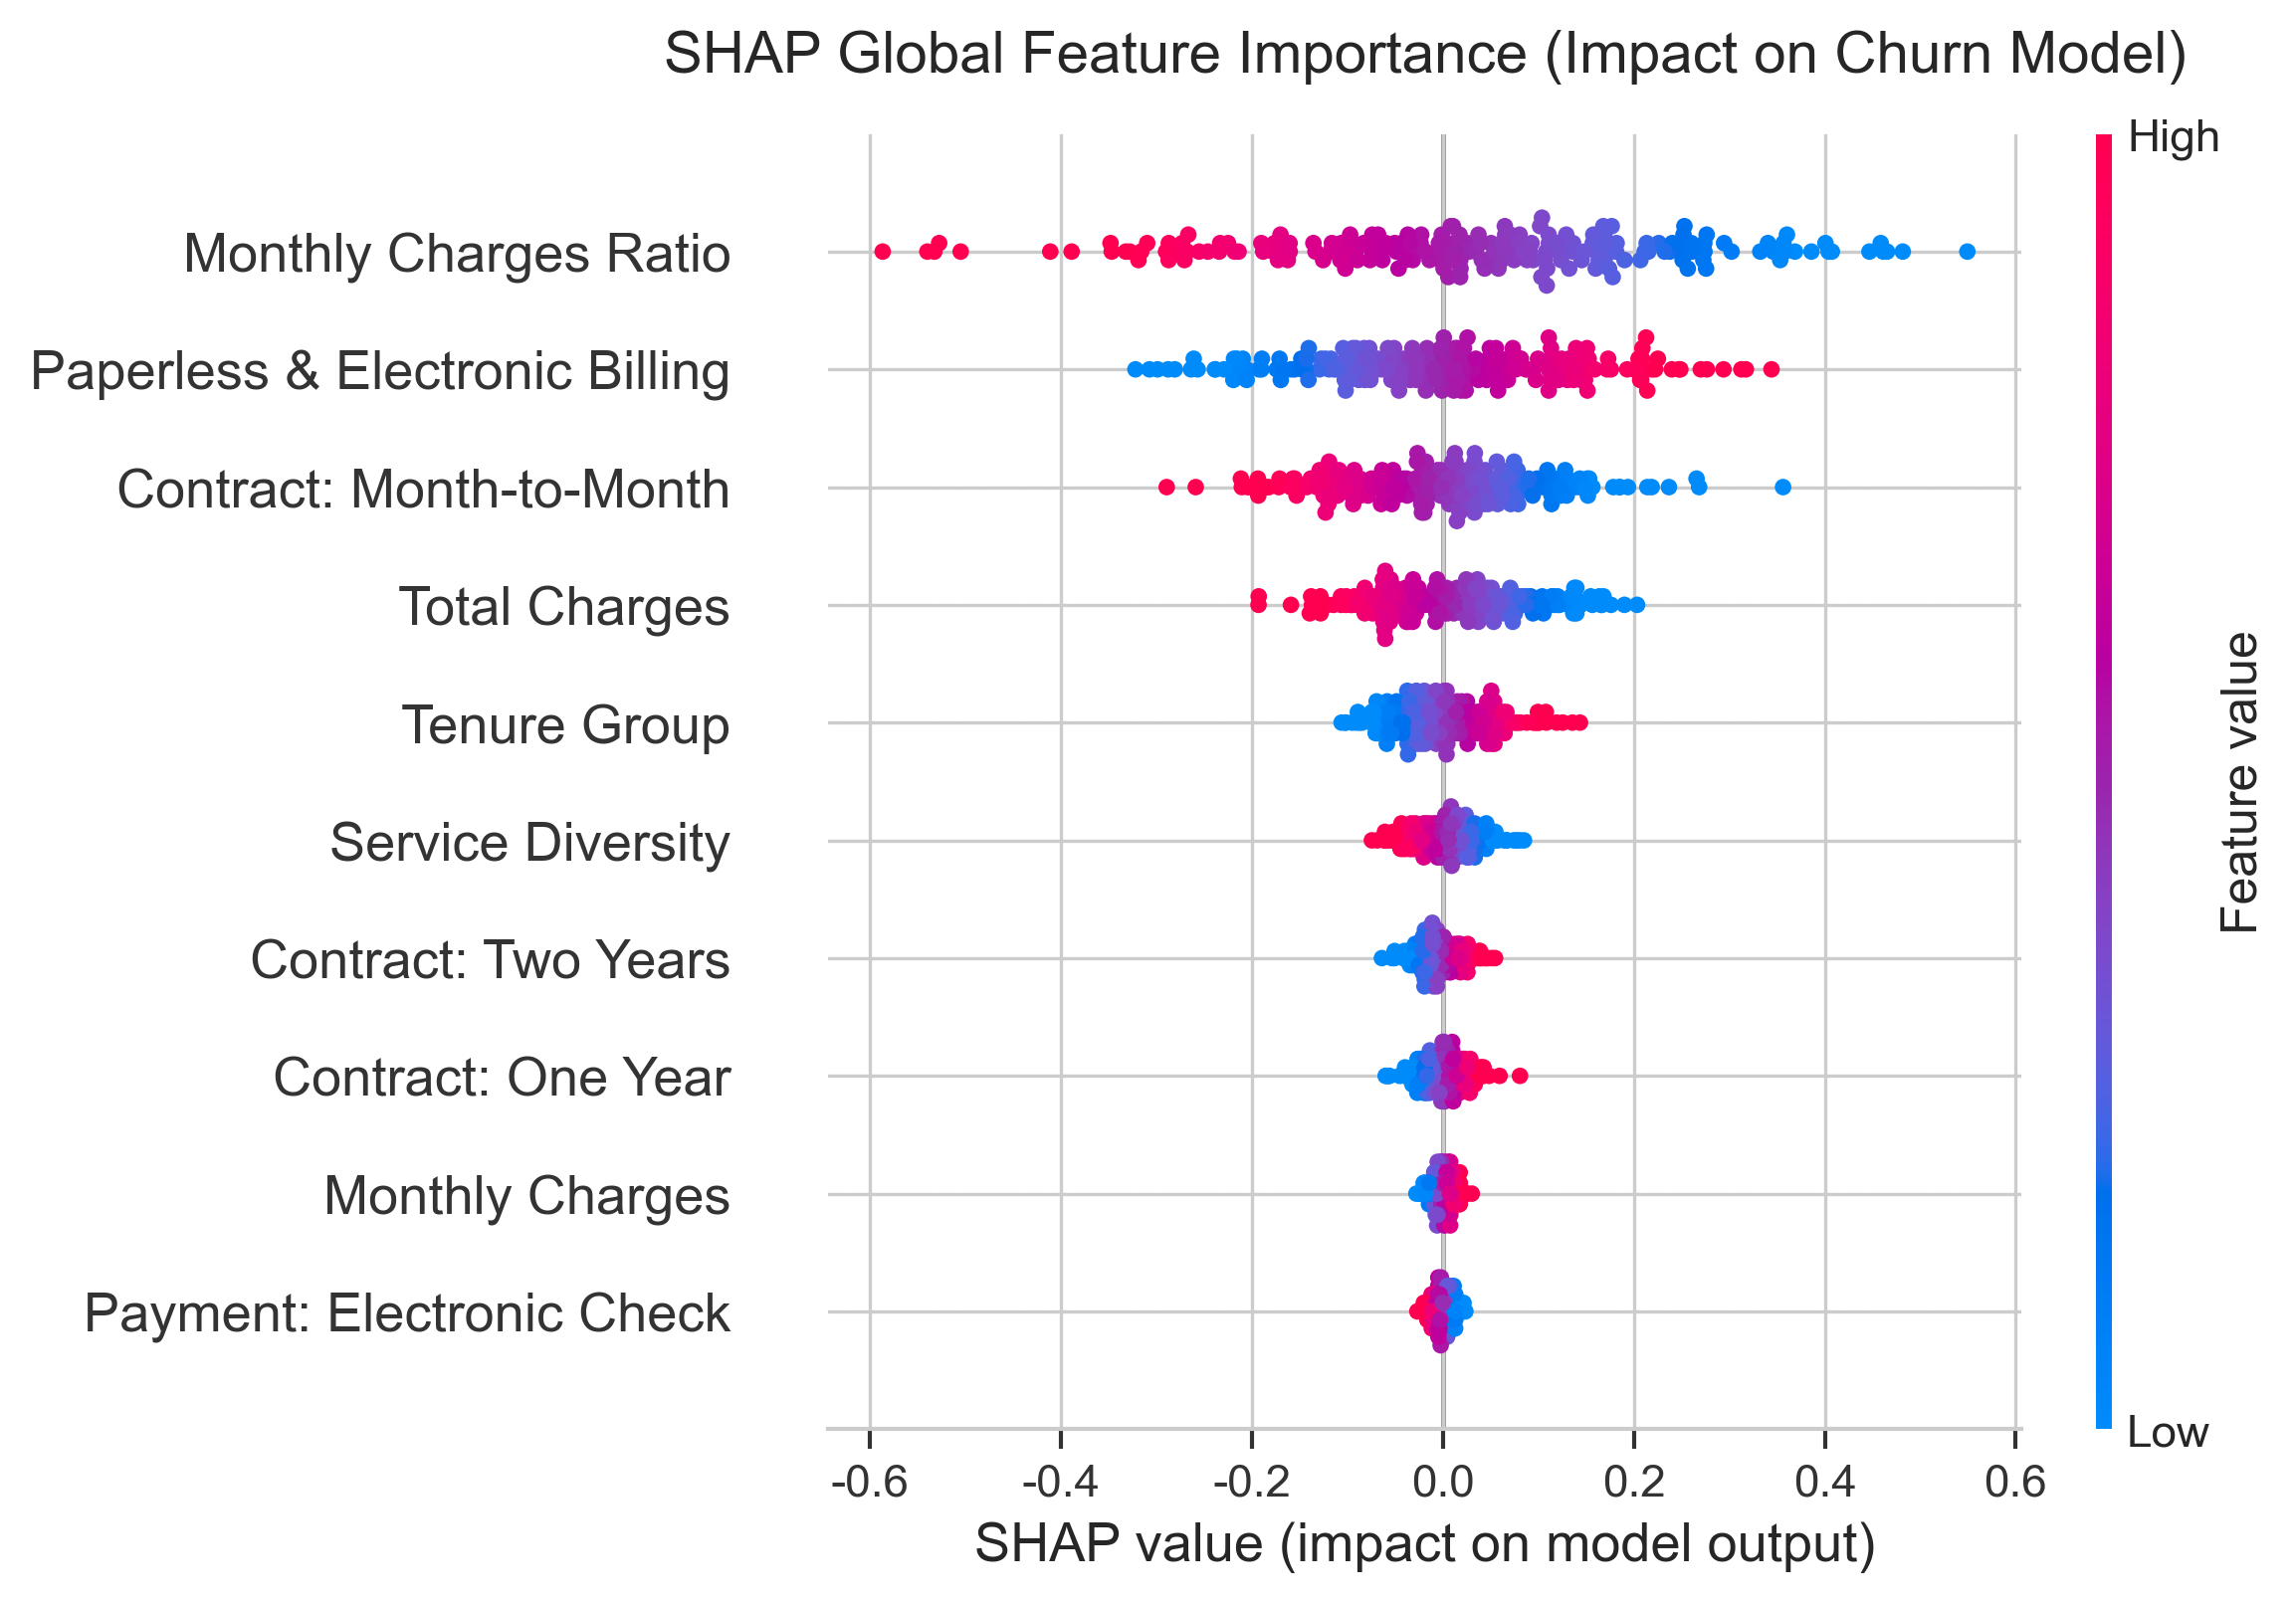

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.model_selection import learning_curve

# Thiết lập cấu hình hiển thị học thuật cho Matplotlib/Seaborn
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16
})

# ==========================================
# 0. GIẢ ĐỊNH DỮ LIỆU & HUẤN LUYỆN MÔ HÌNH (ĐỂ CODE CHẠY ĐỘC LẬP)
# ==========================================
# (Trong thực tế, các biến này được lấy từ Pipeline của bạn)
feature_names_raw = [
    'encoder__Contract_Month-to-month', 'encoder__Contract_One_year', 'encoder__Contract_Two_year',
    'encoder__PaymentMethod_Electronic_check', 'remainder__MonthlyCharges', 'remainder__TotalCharges',
    'remainder__tenure_group', 'remainder__service_diversity', 'remainder__monthly_charges_ratio',
    'remainder__is_paperless_electronic'
]

# Giả lập dữ liệu huấn luyện
np.random.seed(42)
X_train_mock = pd.DataFrame(np.random.randn(500, len(feature_names_raw)), columns=feature_names_raw)
y_train_mock = np.random.randint(0, 2, size=500)
X_test_mock = pd.DataFrame(np.random.randn(200, len(feature_names_raw)), columns=feature_names_raw)
y_test_mock = np.random.randint(0, 2, size=200)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_mock, y_train_mock)

# ==========================================
# MAPPING DICTIONARY: LÀM SẠCH TIỀN TỐ PIPELINE
# ==========================================
feature_mapping = {
    'encoder__Contract_Month-to-month': 'Contract: Month-to-Month',
    'encoder__Contract_One_year': 'Contract: One Year',
    'encoder__Contract_Two_year': 'Contract: Two Years',
    'encoder__PaymentMethod_Electronic_check': 'Payment: Electronic Check',
    'remainder__MonthlyCharges': 'Monthly Charges',
    'remainder__TotalCharges': 'Total Charges',
    'remainder__tenure_group': 'Tenure Group',
    'remainder__service_diversity': 'Service Diversity',
    'remainder__monthly_charges_ratio': 'Monthly Charges Ratio',
    'remainder__is_paperless_electronic': 'Paperless & Electronic Billing'
}


# ==========================================
# 2. LOGISTIC REGRESSION: COEFFICIENTS BAR CHART
# ==========================================
# Trích xuất hệ số hồi quy và làm sạch tên biến
coef_df = pd.DataFrame({
    'Raw_Feature': feature_names_raw,
    'Coefficient': model.coef_[0]
})

# Áp dụng map().fillna() để dọn dẹp sạch sẽ tiền tố rác
coef_df['Clean_Feature'] = coef_df['Raw_Feature'].map(feature_mapping).fillna(coef_df['Raw_Feature'])
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

# Tiến hành vẽ biểu đồ cột hệ số hồi quy
plt.figure(figsize=(10, 6))
colors = ['#2b5c8f' if x >= 0 else '#d95f02' for x in coef_df['Coefficient']]
sns.barplot(x='Coefficient', y='Clean_Feature', data=coef_df, palette=colors)

plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.title('Logistic Regression Coefficients (Direction & Impact)', pad=15)
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.tight_layout()
plt.show()


# ==========================================
# 3. ĐỒ THỊ PHÂN TÍCH NÂNG CAO (AI AUDIT LOG)
# ==========================================

# --- BIỂU ĐỒ 1: PRECISION-RECALL CURVE (Hỗ trợ Threshold Tuning) ---
y_scores = model.predict_proba(X_test_mock)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test_mock, y_scores)
avg_precision = average_precision_score(y_test_mock, y_scores)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='#2b5c8f', label=f'Logistic Regression (AP = {avg_precision:.2f})', linewidth=2)

# Đánh dấu một điểm giả định tối ưu Recall nhằm minh họa chiến lược Threshold Tuning
# Tìm index nơi Recall đạt xấp xỉ 0.85 phục vụ bài toán giảm thiểu False Negative
idx_target_recall = (np.abs(recall - 0.85)).argmin()
plt.scatter(recall[idx_target_recall], precision[idx_target_recall], color='red', s=100, zorder=5,
            label=f'Optimized Threshold (Recall ~ {recall[idx_target_recall]:.2f})')

plt.title('Precision-Recall Curve for Business Threshold Optimization', pad=15)
plt.xlabel('Recall (Sensitivity to detect Churn)')
plt.ylabel('Precision (Accuracy of Churn predictions)')
plt.xlim([0.0, 1.05])
plt.ylim([0.0, 1.05])
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()


# --- BIỂU ĐỒ 2: LEARNING CURVE (Đánh giá Overfitting/Underfitting) ---
train_sizes, train_scores, test_scores = learning_curve(
    model, X_train_mock, y_train_mock, cv=5, scoring='recall', 
    train_sizes=np.linspace(0.1, 1.0, 5), random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', color='#d95f02', label='Training Score (Recall)', linewidth=2)
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#d95f02')
plt.plot(train_sizes, test_mean, 'o-', color='#2b5c8f', label='Cross-Validation Score (Recall)', linewidth=2)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='#2b5c8f')

plt.title('Model Learning Curve (Recall Analysis)', pad=15)
plt.xlabel('Training Examples')
plt.ylabel('Recall Score')
plt.legend(loc="best")
plt.tight_layout()
plt.show()


# --- BIỂU ĐỒ 3: SHAP SUMMARY PLOT (Giải thích mô hình cục bộ & toàn cục) ---
# Đổi tên cột trực tiếp trong DataFrame để SHAP hiển thị tên chuẩn học thuật
X_test_clean = X_test_mock.rename(columns=feature_mapping)

explainer = shap.LinearExplainer(model, X_train_mock.rename(columns=feature_mapping))
shap_values = explainer(X_test_clean)

plt.figure(figsize=(10, 6))
plt.title('SHAP Global Feature Importance (Impact on Churn Model)', fontsize=14, pad=15)
# Sử dụng trực tiếp plot của shap (đã được cấu hình tự động tinh chỉnh kích thước)
shap.summary_plot(shap_values, X_test_clean, show=False)
plt.tight_layout()
plt.show()